<a href="https://colab.research.google.com/github/IreneNakiyingi/Projects/blob/main/Irene_DHSA_AIinHealthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Welcome to AI in Healthcare Tutorial!
This notebook teaches medical professionals how to build and interpret AI models for disease prediction using REAL South African patient data.

You'll learn to:

✅ Build AI models that predict coronary heart disease
✅ Understand WHY the AI makes its decisions (crucial for medical trust!)
✅ Use real data from 462 South African patients
✅ Apply this knowledge to improve patient care
No coding experience required - we'll guide you through everything!

Dataset: South African Heart Disease Study

462 real patients from South Africa
9 clinical variables + 1 outcome (coronary heart disease)
Perfect for learning medical AI with African healthcare context """
Remember the AI implementation cycle:
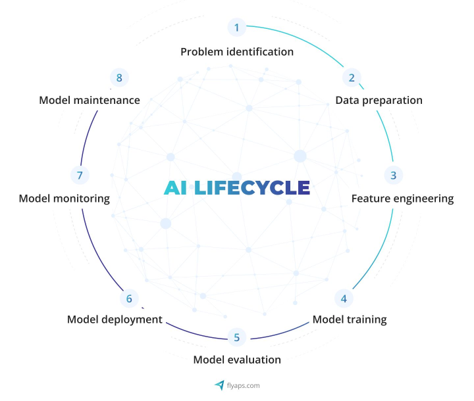

  Load pacakages

In [1]:
# Install required packages for Google Colab
print("📦 Installing AI and visualization libraries...")

# Install SHAP (the most important library for explainable AI)
!pip install shap --quiet

# Install other required libraries that might not be in Colab by default
!pip install scikit-learn --upgrade --quiet
!pip install seaborn --upgrade --quiet

print("✅ All libraries installed successfully!")

📦 Installing AI and visualization libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 82.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.
✅ All libraries installed successfully!


In [2]:
# Import all necessary libraries
print("\n📚 Importing libraries...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import shap
import warnings
warnings.filterwarnings('ignore')

# Set up beautiful plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")


📚 Importing libraries...
✅ All libraries imported successfully!


Data loading, EDA

In [3]:
# Load the South African Heart Disease dataset
df = pd.read_csv('SAHeart.csv')

# Remove the row.names column if it exists (it's just an index)
if 'row.names' in df.columns:
    df = df.drop('row.names', axis=1)

print("🏥 SUCCESS: South African Heart Disease Dataset Loaded!")
print(f"   📊 Total patients in study: {len(df)}")
print(f"   ❤️  Patients with coronary heart disease: {df['chd'].sum()} ({df['chd'].mean():.1%})")
print(f"   💚 Healthy patients: {len(df) - df['chd'].sum()} ({(1-df['chd'].mean()):.1%})")


🏥 SUCCESS: South African Heart Disease Dataset Loaded!
   📊 Total patients in study: 462
   ❤️  Patients with coronary heart disease: 160 (34.6%)
   💚 Healthy patients: 302 (65.4%)


In [4]:
# Create a dictionary for descriptive variable names (important for medical interpretation)
descriptive_names = {
    'sbp': 'Systolic Blood Pressure (mmHg)',
    'tobacco': 'Cumulative Tobacco Use (kg)',
    'ldl': 'LDL Cholesterol Level (mg/dL)',
    'adiposity': 'Adiposity Index',
    'famhist': 'Family History of Heart Disease',
    'typea': 'Type-A Behavior Score',
    'obesity': 'Obesity Index',
    'alcohol': 'Current Alcohol Consumption',
    'age': 'Age at Onset (years)',
    'chd': 'Coronary Heart Disease (CHD)'
}

print("\n📋 Clinical Variables in Our Dataset:")
for var, desc in descriptive_names.items():
    if var in df.columns:
        print(f"   • {var:10} → {desc}")



📋 Clinical Variables in Our Dataset:
   • sbp        → Systolic Blood Pressure (mmHg)
   • tobacco    → Cumulative Tobacco Use (kg)
   • ldl        → LDL Cholesterol Level (mg/dL)
   • adiposity  → Adiposity Index
   • famhist    → Family History of Heart Disease
   • typea      → Type-A Behavior Score
   • obesity    → Obesity Index
   • alcohol    → Current Alcohol Consumption
   • age        → Age at Onset (years)
   • chd        → Coronary Heart Disease (CHD)


In [5]:
# Loading first 5 records
print("\n👥 First 5 South African patients in our dataset:")
print(df.head())


👥 First 5 South African patients in our dataset:
   sbp  tobacco   ldl  adiposity  famhist  typea  obesity  alcohol  age  chd
0  160    12.00  5.73      23.11  Present     49    25.30    97.20   52    1
1  144     0.01  4.41      28.61   Absent     55    28.87     2.06   63    1
2  118     0.08  3.48      32.28  Present     52    29.14     3.81   46    0
3  170     7.50  6.41      38.03  Present     51    31.99    24.26   58    1
4  134    13.60  3.50      27.78  Present     60    25.99    57.34   49    1
